###Objective:
You are required to model the progression of diabetes using the available independent
variables. This model will help healthcare professionals understand how different factors
influence the progression of diabetes and potentially aid in designing better treatment
plans and preventive measures. The model will provide insights into the dynamics of
diabetes progression in patients.

### Complete work flow

Load Dataset

     ↓
Understand Dataset

     ↓
Check Missing Values

     ↓
EDA / Visualization

     ↓
Train-Test Split

     ↓
Normalize Features

     ↓
Build ANN

     ↓
Compile Model

     ↓
Train Model

     ↓
Evaluate Model

     ↓
Improve Model

     ↓
Compare Results
     

## Step 1 — Import libraries

In [106]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Load the dataset

In [107]:
diabetes = load_diabetes()
print(diabetes)

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]]), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
  

In [108]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


## Step 3 — Create X and y

In [109]:
X = diabetes.data
y = diabetes.target

In [110]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


442 patients
   
10 features
   
1 target value

## Step 4 — Convert to DataFrame

In [111]:
df = pd.DataFrame(X, columns=diabetes.feature_names)

df['target'] = y

In [112]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Step 5 — Understand the data

In [113]:
df.shape

(442, 11)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [115]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [116]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


no missing values

## Step 7 — Exploratory Data Analysis (EDA)

### Distribution of target

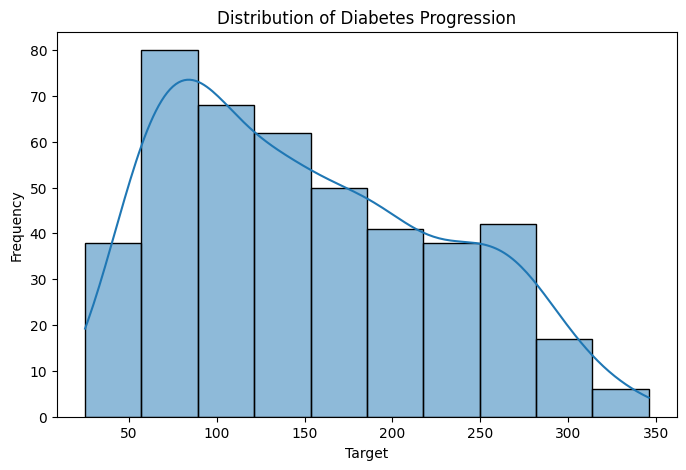

In [117]:
plt.figure(figsize=(8,5))

sns.histplot(df['target'], kde=True)

plt.title('Distribution of Diabetes Progression')
plt.xlabel('Target')
plt.ylabel('Frequency')

plt.show()

### Check feature distributions

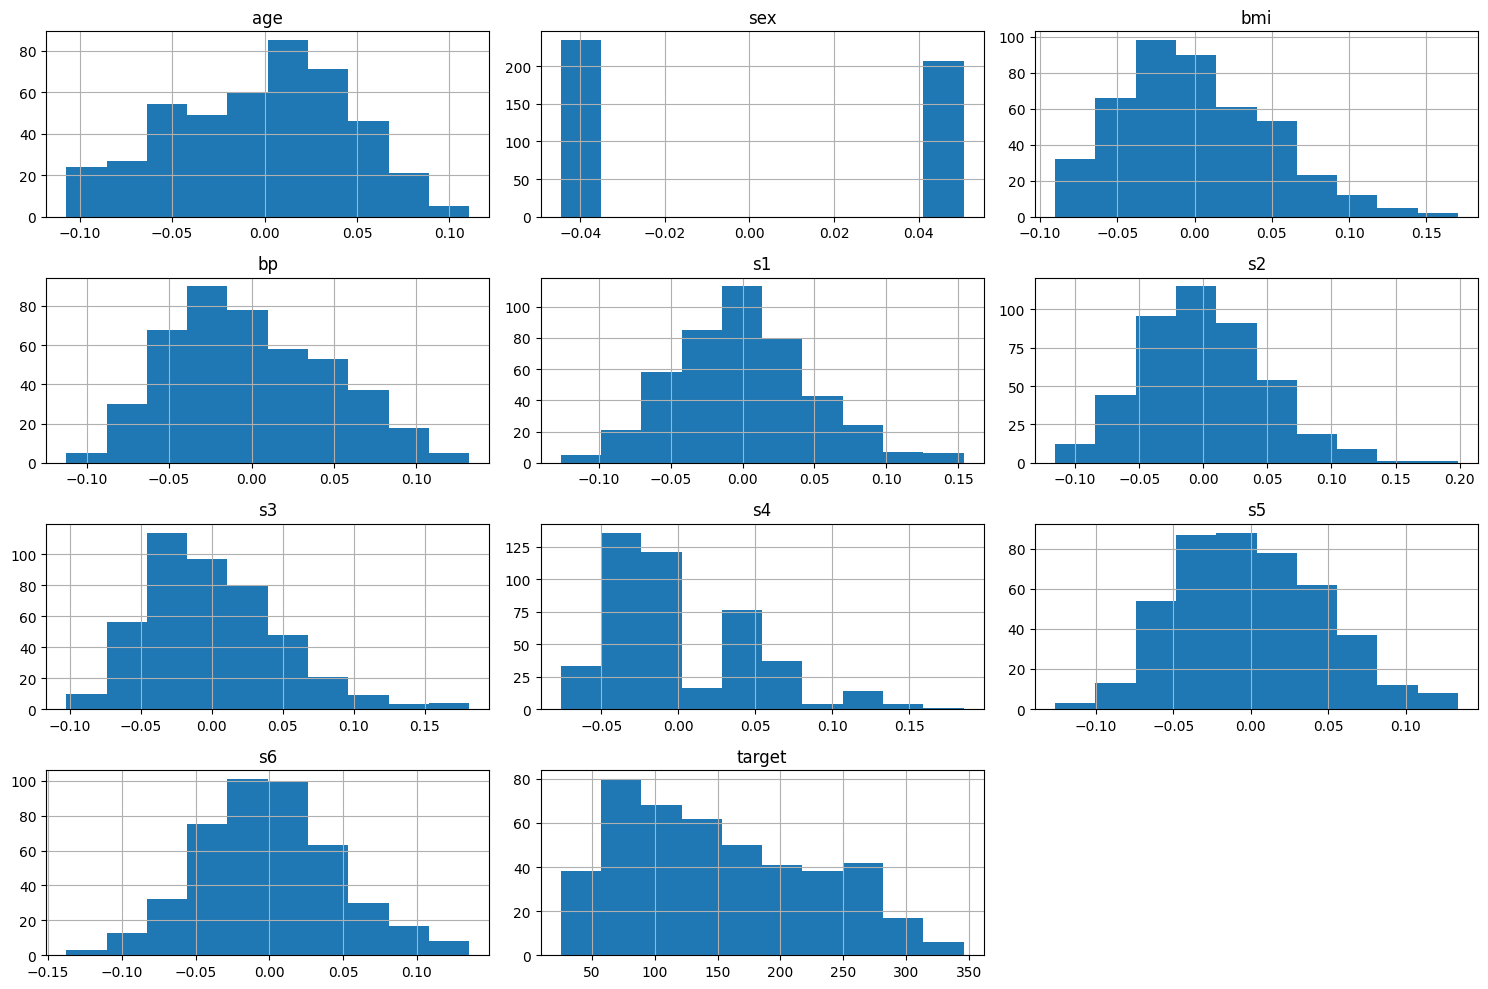

In [118]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

### Check correlation

Correlation tells us how strongly two variables are related.

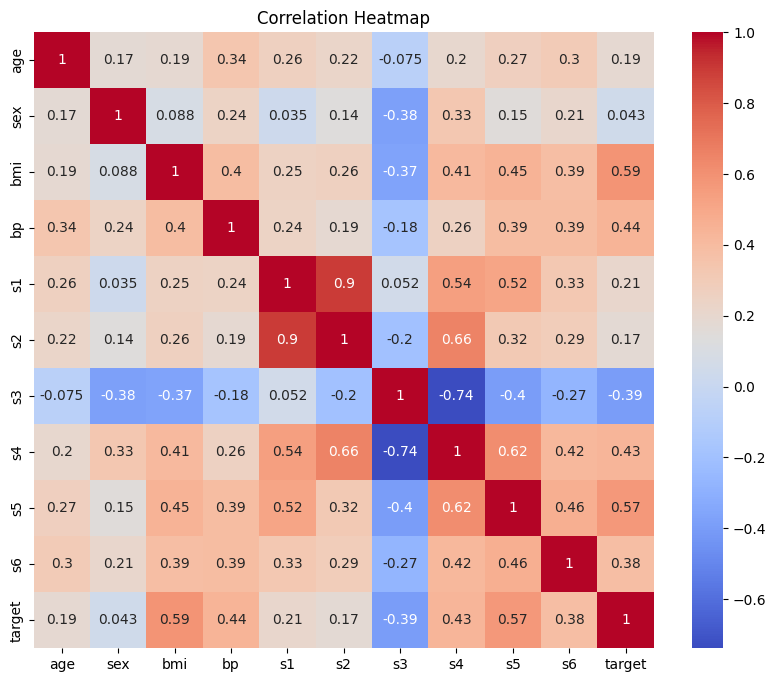

In [119]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

 ### Relationship between features and target

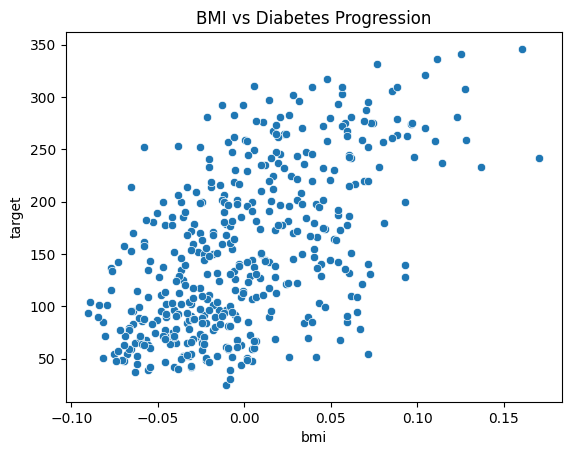

In [120]:
sns.scatterplot(data=df, x='bmi', y='target')

plt.title('BMI vs Diabetes Progression')
plt.show()

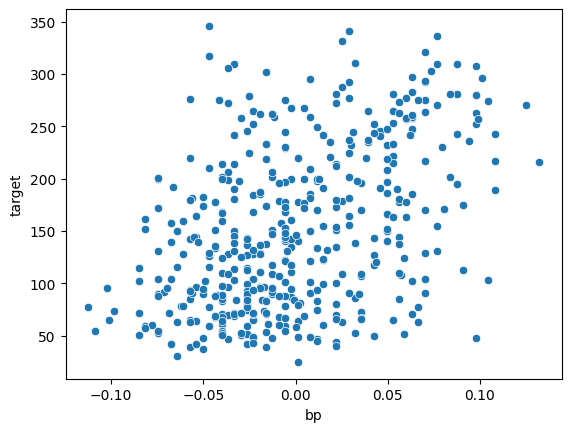

In [121]:
sns.scatterplot(data=df, x='bp', y='target')
plt.show()

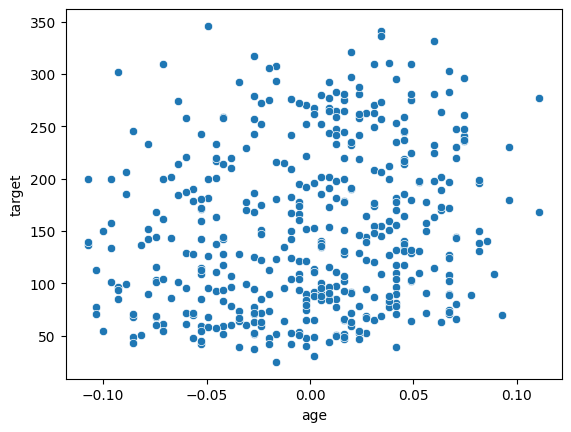

In [122]:
sns.scatterplot(data=df, x='age', y='target')
plt.show()

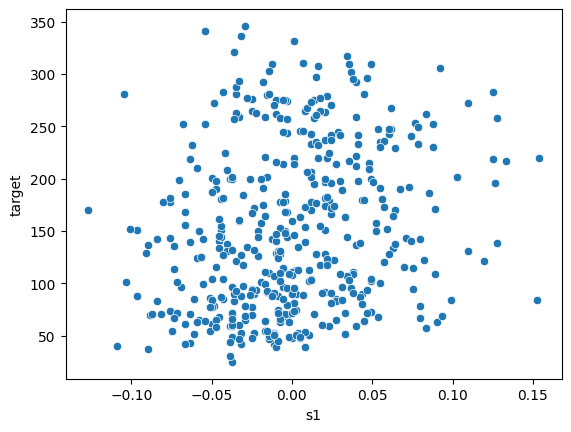

In [123]:
sns.scatterplot(data=df, x='s1', y='target')
plt.show()

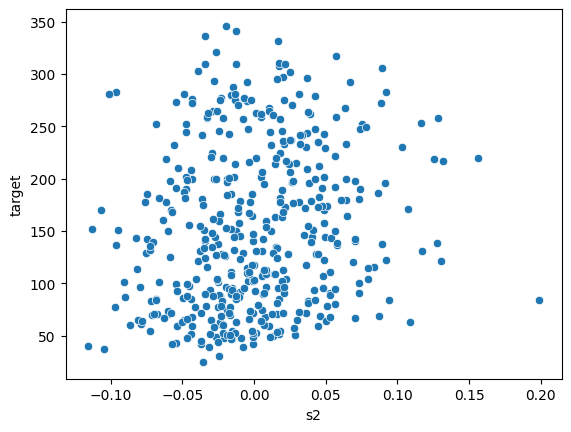

In [124]:
sns.scatterplot(data=df, x='s2', y='target')
plt.show()

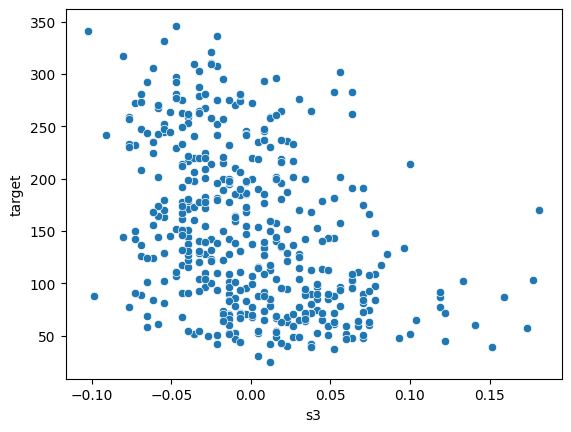

In [125]:
sns.scatterplot(data=df, x='s3', y='target')
plt.show()

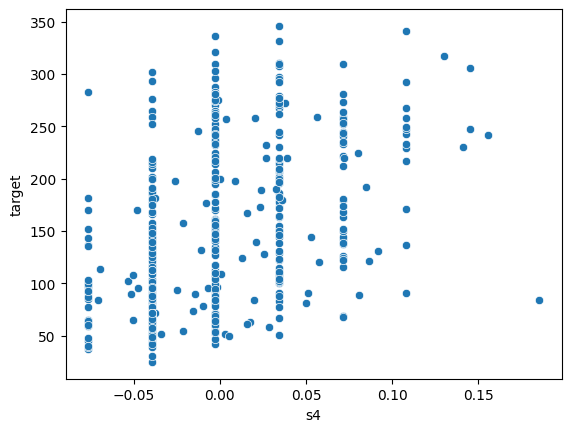

In [126]:
sns.scatterplot(data=df, x='s4', y='target')
plt.show()

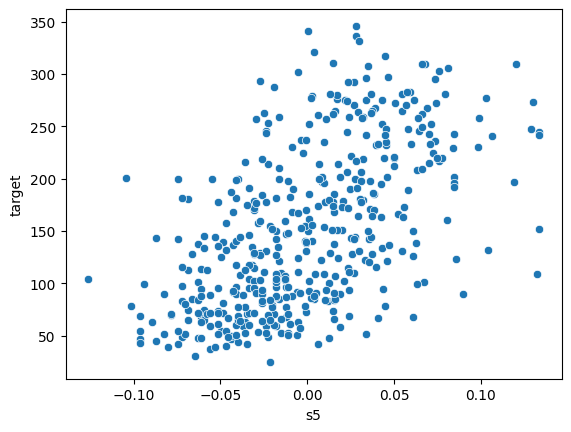

In [127]:
sns.scatterplot(data=df, x='s5', y='target')
plt.show()

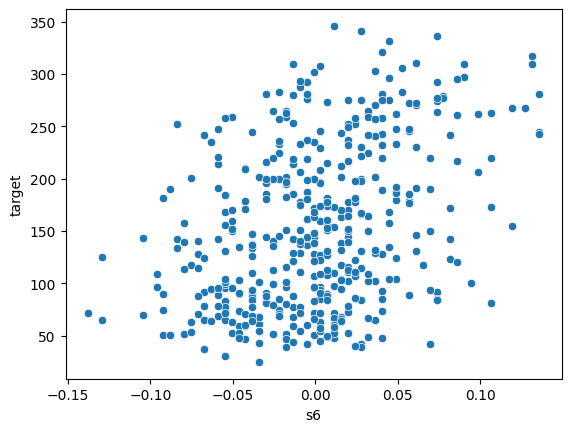

In [128]:
sns.scatterplot(data=df, x='s6', y='target')
plt.show()

## Step 8 — Separate X and y

In [129]:
X = diabetes.data
y = diabetes.target

## Step 9 — Train-Test Split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 10 — Normalize the features

In [131]:
scaler = StandardScaler()

In [132]:
X_train_scaled = scaler.fit_transform(X_train)

In [133]:
X_test_scaled = scaler.transform(X_test)

## Step 11 — Build the ANN

In [134]:
model = Sequential()

In [135]:
model.add(
    Dense(
        64,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    )
)

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

## Step 12 — Compile the ANN

In [136]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

## Step 13 — Check model architecture

In [137]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 14 — Train the ANN

In [138]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 31132.0352 - mae: 157.5273 - val_loss: 22028.1523 - val_mae: 132.4628
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30623.6641 - mae: 156.0095 - val_loss: 21592.5645 - val_mae: 130.9073
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29877.5039 - mae: 153.7992 - val_loss: 20951.5273 - val_mae: 128.6303
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28746.7012 - mae: 150.4532 - val_loss: 20024.4434 - val_mae: 125.3207
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27102.6230 - mae: 145.5148 - val_loss: 18733.3867 - val_mae: 120.6332
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24844.4316 - mae: 138.4786 - val_loss: 17038.4492 - val_mae: 114.2324
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21957.7617 - mae: 128.8935 - val_loss: 14966.7236 - val_mae: 105.8537
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18583.0820 - mae: 116.7798 - val_loss

## Step 15 — Plot training loss

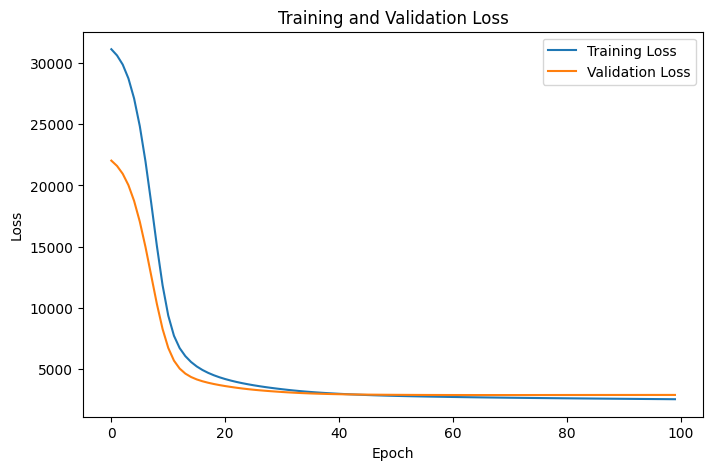

In [139]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

## Step 16 — Make predictions

In [140]:
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


## Step 17 — Evaluate using MSE,MAE

In [141]:
mse = mean_squared_error(y_test, y_pred)


mae = mean_absolute_error(
    y_test,
    y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 2779.3744170223868
Mean Absolute Error: 42.49786059776049


## Step 18 — R² Score

In [142]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.47540679298199273


## Step 19 — Compare Actual vs Predicted

In [143]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

results.head(10)

,Actual,Predicted
0,219.0,162.000854
1,70.0,191.408447
2,202.0,141.805756
3,230.0,300.638184
4,111.0,91.931694
5,84.0,117.180305
6,242.0,269.491486
7,272.0,175.611816
8,94.0,87.114548
9,96.0,74.992065


## Step 20 — Plot Actual vs Predicted

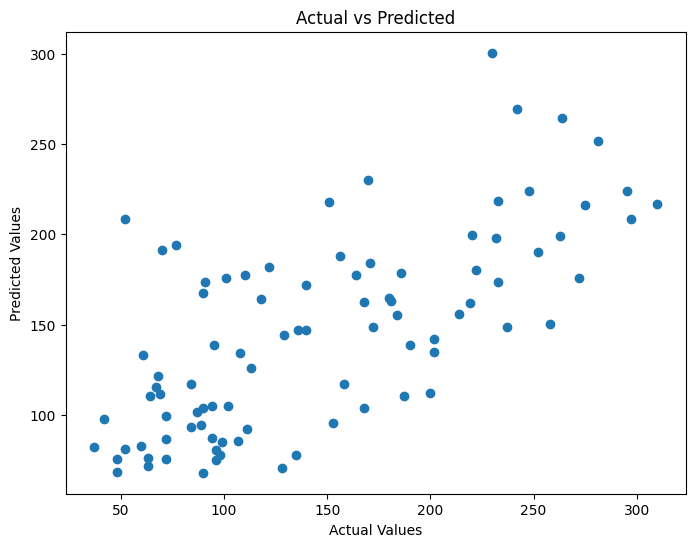

In [144]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

plt.show()

## Step 21 — Improve the model
Assignment requirement:

Experiment with different architectures,activation functions, or hyperparameters.
Improved model:

128 neurons

64 neurons

32 neurons

EarlyStopping

200 maximum epochs

In [145]:
improved_model = Sequential()


# Hidden Layer 1
improved_model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    )
)
# Hidden Layer 2
improved_model.add(
    Dense(
        64,
        activation="relu"
    )
)
# Hidden Layer 3
improved_model.add(
    Dense(
        32,
        activation="relu"
    )
)
# Output Layer
improved_model.add(
    Dense(
        1
    )
)

## step 22 -  Improved Model Summary

In [146]:
print("\nImproved ANN Model Summary:")

improved_model.summary()



Improved ANN Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 23 -  Compile Improved Model

In [147]:
improved_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 24 - Early Stopping

In [148]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)


## Step 25 - Train Improved Model

In [149]:
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 31428.4082 - mae: 158.3530 - val_loss: 22248.5957 - val_mae: 133.2174
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30833.0000 - mae: 156.5637 - val_loss: 21446.3398 - val_mae: 130.3370
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28831.7988 - mae: 150.5790 - val_loss: 19002.2422 - val_mae: 121.3203
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23327.5352 - mae: 132.9292 - val_loss: 13462.2324 - val_mae: 98.2992
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13377.5039 - mae: 94.5403 - val_loss: 6093.7388 - val_mae: 57.7367
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6266.8999 - mae: 60.5658 - val_loss: 3637.0312 - val_mae: 46.1718
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4981.0503 - mae: 55.9231 - val_loss: 3385.4780 - val_mae: 43.4433
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4271.5220 - mae: 51.6174 - val_loss: 3248.7756 - 

## Step 26 - Plot Improved Model Loss

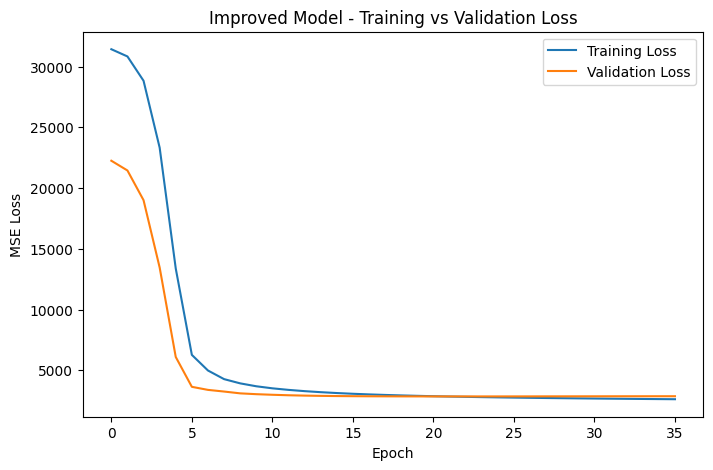

In [150]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Improved Model - Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.show()

## Step 27 - Improved Model Predictions

In [151]:
improved_pred = improved_model.predict(
    X_test_scaled,
    verbose=0
)

improved_pred = improved_pred.flatten()


## Step 28 - Improved Model Evaluation

In [152]:
improved_mse = mean_squared_error(
    y_test,
    improved_pred
)

improved_mae = mean_absolute_error(
    y_test,
    improved_pred
)

improved_r2 = r2_score(
    y_test,
    improved_pred
)


print("\n==============================")
print("IMPROVED MODEL RESULTS")
print("==============================")

print("Mean Squared Error :", improved_mse)
print("Mean Absolute Error:", improved_mae)
print("R2 Score           :", improved_r2)



IMPROVED MODEL RESULTS
Mean Squared Error : 2982.141018637513
Mean Absolute Error: 43.36728445331702
R2 Score           : 0.4371355974331115


## Step 29 -Improved Actual VS Predicted

In [153]:
improved_results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": improved_pred

})

print("\nImproved Model - Actual vs Predicted:")
print(improved_results.head(10))



Improved Model - Actual vs Predicted:
   Actual   Predicted
0   219.0  165.682007
1    70.0  194.428101
2   202.0  144.290344
3   230.0  330.810883
4   111.0   84.493935
5    84.0  106.480682
6   242.0  267.848785
7   272.0  174.495789
8    94.0  103.102066
9    96.0   68.670265


## Step 30 - Improved Model Visulaization

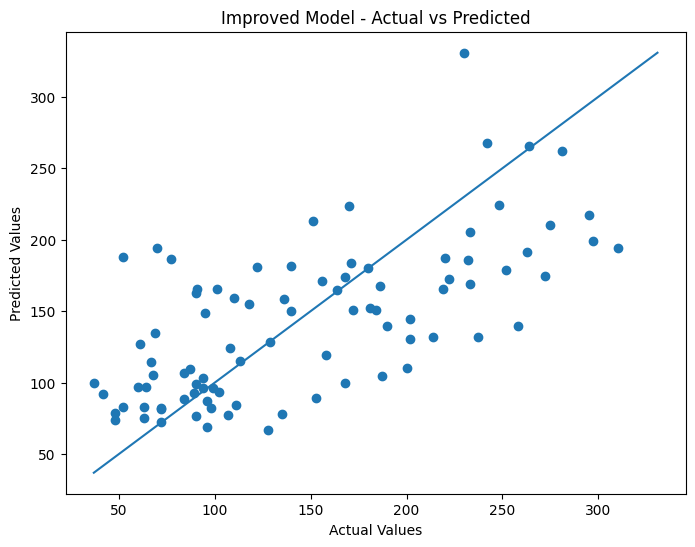

In [154]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    improved_pred
)

minimum = min(
    y_test.min(),
    improved_pred.min()
)

maximum = max(
    y_test.max(),
    improved_pred.max()
)
plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Improved Model - Actual vs Predicted")

plt.show()


## Step 31 - Model Comparision

In [155]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline ANN",
        "Improved ANN"
    ],

    "MSE": [
        mse,
        improved_mse
    ],

    "MAE": [
        mae,
        improved_mae
    ],

    "R2 Score": [
        r2,
        improved_r2
    ]

})
print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)


MODEL COMPARISON
          Model          MSE        MAE  R2 Score
0  Baseline ANN  2779.374417  42.497861  0.475407
1  Improved ANN  2982.141019  43.367284  0.437136


## FINAL CONCLUSION

This project used the Diabetes dataset from scikit-learn
to predict diabetes progression using an Artificial Neural
Network.

The dataset was explored and checked for missing values.
The input features were normalized using StandardScaler.

A baseline ANN model was created using Dense layers and
ReLU activation functions. The model was trained using
the Adam optimizer and Mean Squared Error loss function.

The model was evaluated using:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- R2 Score
An improved ANN architecture was then created by increasing
the number of hidden layers and neurons. EarlyStopping was
also used to prevent unnecessary training.

Finally, the  Baseline ANN and improved ANN models were compared
using their MSE, MAE, and R2 scores

## Step 33 - FINAL RESULTS TABLE

In [156]:
print("\nFINAL MODEL COMPARISON:")

display(comparison)


FINAL MODEL COMPARISON:


,Model,MSE,MAE,R2 Score
0,Baseline ANN,2779.374417,42.497861,0.475407
1,Improved ANN,2982.141019,43.367284,0.437136
